In [2]:
import pandas as pd


df=pd.read_csv('diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
764,2,122.0,70.0,27.0,NaN,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,NaN,NaN,30.1,0.349,47,1


In [2]:
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [3]:
mean=df['Glucose'].mean()

df['Glucose']=df['Glucose'].fillna(mean)

In [4]:
df.isnull().sum()

Pregnancies                   0
Glucose                       0
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [5]:
most_frequent=df['BloodPressure'].mean()
df['BloodPressure']=df['BloodPressure'].fillna(most_frequent)

In [6]:
df.isnull().sum()

Pregnancies                   0
Glucose                       0
BloodPressure                 0
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
mean=df['SkinThickness'].mean()
df['SkinThickness']=df['SkinThickness'].fillna(mean)

In [10]:
df.isnull().sum()

Pregnancies                   0
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [16]:
x=df['Insulin'].mode()
df['Insulin']=df['Insulin'].fillna(x)

In [17]:
df.isnull().sum()

Pregnancies                   0
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                     373
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [23]:
mode=df['Insulin'].mean()
df['Insulin']=df['Insulin'].fillna(mode)

In [24]:
df.isnull().sum()

Pregnancies                  0
Glucose                      0
BloodPressure                0
SkinThickness                0
Insulin                      0
BMI                         11
DiabetesPedigreeFunction     0
Age                          0
Outcome                      0
dtype: int64

In [25]:
mode=df['BMI'].mean()
df['BMI']=df['BMI'].fillna(mode)

In [26]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [28]:
df.to_csv('Cleaned_diabetes.csv')

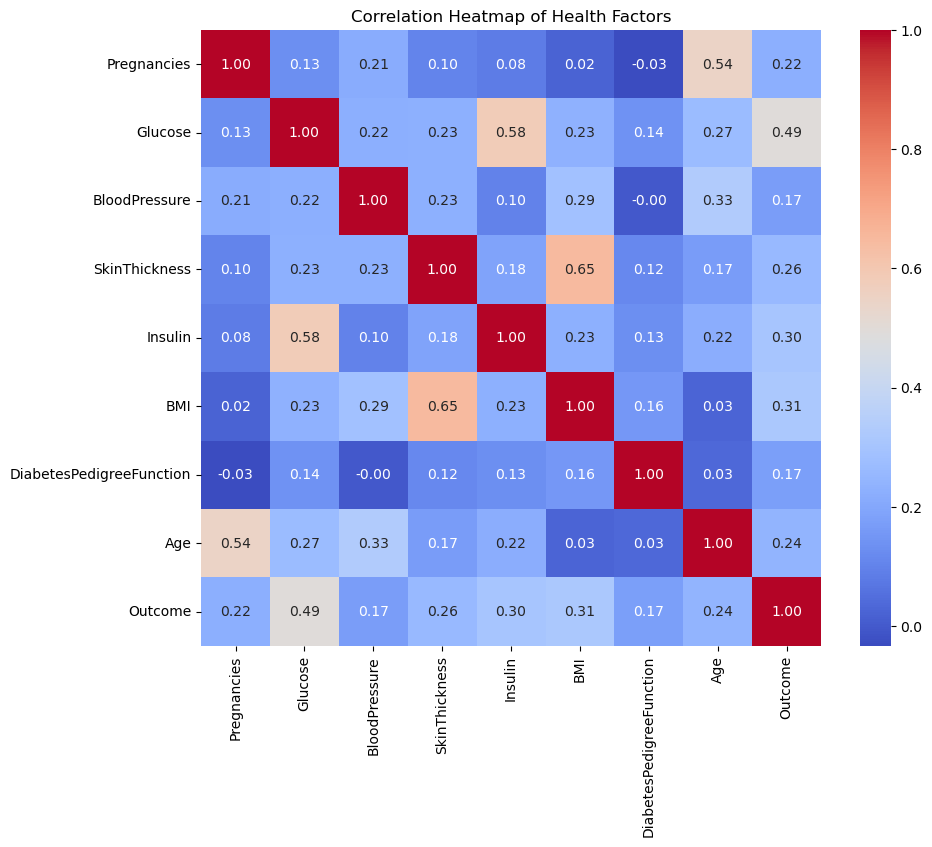

In [3]:
import seaborn as sns
import matplotlib.pyplot as pIt

pIt.figure(figsize=(10, 8))
correlation=df.corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
pIt.title('Correlation Heatmap of Health Factors')
pIt.show()

The Insights:Look at the outcome row. Columns with number closest to 1.0(likely glucose) have the strongest positive relationship with diabetes
    

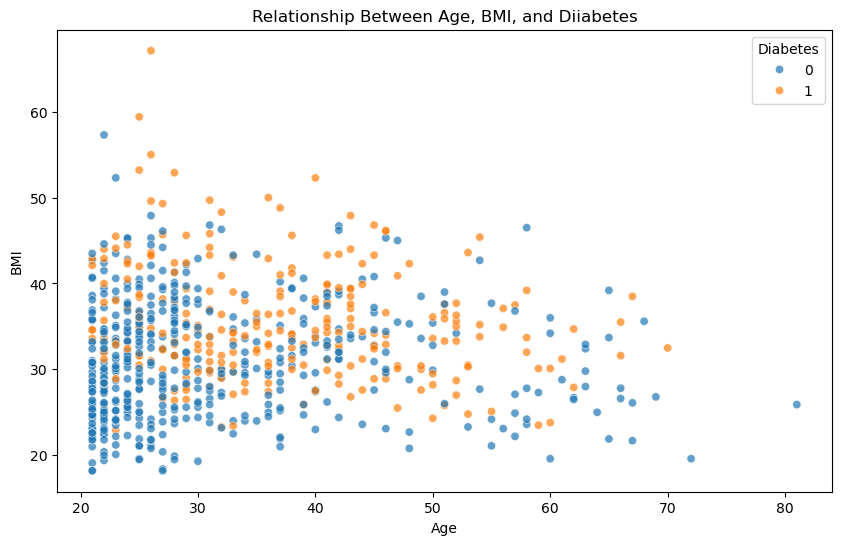

In [4]:
pIt.figure(figsize=(10, 6))

# Scatter plot with color representing the outcome
scatter=sns.scatterplot(x='Age', y='BMI', hue='Outcome', data=df, alpha=0.7)

pIt.title('Relationship Between Age, BMI, and Diiabetes')
pIt.xlabel('Age')
pIt.ylabel('BMI')
pIt.legend(title='Diabetes', loc='upper right')

pIt.show()

Insights


Clusters:You might notice that "Outcome 1" (diabetic) points are more concentrated in higher BMI and higher Age region

Trends: It helps you visualize if diabetes is more common in younger people with high BMI or older people regardless of BMI  

C:\Users\NEW\AppData\Local\Temp\ipykernel_34652\3254123835.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y='Glucose', data=df, palette='Set2')


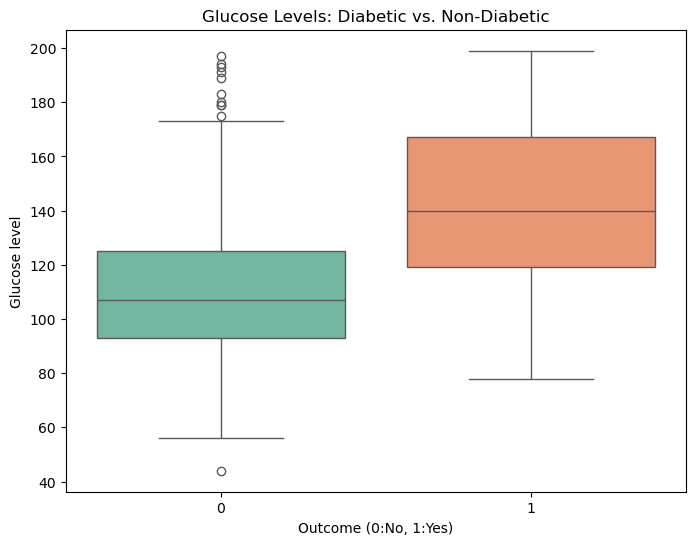

In [9]:
pIt.figure(figsize=(8, 6))
# Create a boxplot to compare Glucose levels for each Outcome

sns.boxplot(x='Outcome', y='Glucose', data=df, palette='Set2')

pIt.title('Glucose Levels: Diabetic vs. Non-Diabetic')
pIt.xlabel('Outcome (0:No, 1:Yes)')
pIt.ylabel('Glucose level')
pIt.show()

Insights:

1. The boxes don't overlap that much, Glucose is an excellent predictor

2. The dots above or below the whiskers show patients with unusually high or low glucose levels for their group